# Analiza podatkov za VNL 2026

V tem zvezku analiziram podatke o igralcih in igralkah Volleyball Nations League - VNL 2026 (moška in ženska liga), ki sem jih zbrala s spletne strani volleyballworld.com.

Analiza vsebuje:




## Priprava

### Uvoz knjižnic

- **pandas** - knjižnica za delo s tabelami podatkov (podobno Excelu, ampak v Pythonu)
- **matplotlib** - knjižnica za risanje grafov

In [552]:
import pandas as pd
import matplotlib.pyplot as plt

### Nalaganje podatkov

In [553]:
moski = pd.read_csv("igralci_moski.csv")
zenske = pd.read_csv("igralci_zenske.csv")

moski["spol"] = "M"
zenske["spol"] = "Ž"

igralci = pd.concat([moski, zenske], ignore_index=True)

### Čiščenje podatkov

Popravila bom tri vrste stolpcev:
1. **visina_cm**  (besedilo kot `"175cm"`) - odstranila bom `"cm"` in pretvorila string v število.
2. **Odstotkovni stolpci** (`ucinkovitost_napad`, `uspesnost_blok`, `uspesnost_servis`) (besedilo kot `"50.00%"`) - odstranila bom `"%"` in pretvorila v število.
3. **Ostali številčni stolpci** - nekateri igralci imajo namesto števila zapisan pomišljaj `"-"` (če še niso odigrali nobene tekme). `pd.to_numeric(..., errors="coerce")` tak primer spremeni v `NaN` (manjkajoča vrednost).

In [554]:
igralci["visina_cm"] = igralci["visina_cm"].str.replace("cm", "")
igralci["visina_cm"] = pd.to_numeric(igralci["visina_cm"], errors="coerce")


stolpci_odstotki = ["ucinkovitost_napad", "uspesnost_blok", "uspesnost_servis"]
for stolpec in stolpci_odstotki:
    igralci[stolpec] = igralci[stolpec].astype(str).str.replace("%", "")
    igralci[stolpec] = pd.to_numeric(igralci[stolpec], errors="coerce")


stolpci_stevilke = [
    "starost", "tocke_skupaj", "tocke_povprecje", "tocke_napad", "napad_povprecje",
    "tocke_blok", "blok_povprecje", "tocke_servis", "servis_povprecje",
]


for stolpec in stolpci_stevilke:
    igralci[stolpec] = pd.to_numeric(igralci[stolpec], errors="coerce")

## 1. Povprečna starost in višina (moški, ženske, primerjava)

Najprej si poglejmo povprečno starost in višino pri moških, urejeno po višini (padajoče).

In [555]:
moski_starost = (
    igralci[igralci["spol"] == "M"]
    .groupby("drzava")[["starost", "visina_cm"]]
    .mean()
    .round(1)
    .sort_values(by="visina_cm", ascending=False)
)

moski_starost_tabela = moski_starost.reset_index()
moski_starost_tabela.index += 1
moski_starost_tabela.columns = ["Država", "Povpr. starost", "Povpr. višina"]
moski_starost_tabela

,Država,Povpr. starost,Povpr. višina
1,Turčija,26.1,199.8
2,Bolgarija,23.7,199.3
3,Poljska,28.3,199.3
4,ZDA,28.7,198.7
5,Slovenija,25.9,198.5
6,Kuba,26.8,198.1
7,Srbija,25.8,197.9
8,Iran,22.9,197.4
9,Brazilija,27.4,197.1
10,Ukrajina,28.3,197.0


Opazimo lahko (nepresenetljivo), da so v povprečju najnižji Japonci. Vidimo lahko tudi, da so Slovenci zelo visoko na lestvici. 

Zanimivo je, da je povprečna višina Turčije (v povprečju najvišje ekipe) kar 199.8 cm, torej skoraj 2 metra. Prav tako niti povprečna višina Japonske ne pade pod 190 cm. To pove, da je v odbojki vse pomembnejša višina, ki včasih ni igrala tako ključne vloge v odbojki.


Poglejmo si enako tabelo še za ženske.

In [556]:
zenske_starost = (
    igralci[igralci["spol"] == "Ž"]
    .groupby("drzava")[["starost", "visina_cm"]]
    .mean()
    .round(1)
    .sort_values(by="visina_cm", ascending=False)
)

zenske_starost_tabela = zenske_starost.reset_index()
zenske_starost_tabela.index += 1
zenske_starost_tabela.columns = ["Država", "Povpr. starost", "Povpr. višina"]
zenske_starost_tabela

,Država,Povpr. starost,Povpr. višina
1,Kitajska,22.8,186.9
2,Dominikanska republika,26.7,186.7
3,Turčija,24.8,186.4
4,Brazilija,27.4,186.2
5,Nizozemska,24.4,186.1
6,ZDA,27.8,185.9
7,Nemčija,24.1,185.8
8,Srbija,25.1,185.1
9,Poljska,25.8,184.8
10,Italija,26.3,184.6


Tu lahko opazimo zelo zanimivo nasprotje - vidimo, da so v povprečju najvišje Kitajke, ki na splošno ne veljajo za najvišje. Preostali dve azijski ekipi sta pričakovano na zadnjih dveh mestih.


Poglejmo si še primerjavo po povprečni starosti med moškimi in ženskami (za tiste ekipe, kjer država nastopa tako v moški kot v ženski kategoriji).

In [557]:
primerjava_starosti = (
    igralci.groupby(["drzava", "spol"])["starost"]
    .mean()
    .round(1)
    .unstack()
    .dropna()
)

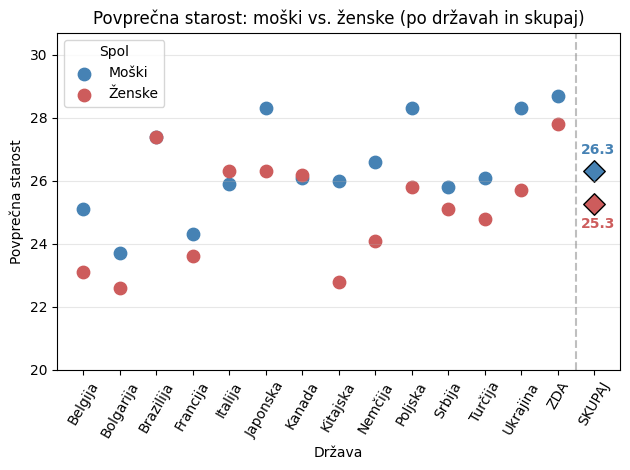

In [558]:
x = range(len(primerjava_starosti))

povprecje_vsi = igralci.groupby("spol")["starost"].mean()

plt.scatter(x, primerjava_starosti.iloc[:, 0], color="steelblue", label="Moški", s=80)
plt.scatter(x, primerjava_starosti.iloc[:, 1], color="indianred", label="Ženske", s=80)

x_skupaj = len(primerjava_starosti)

plt.scatter(x_skupaj, povprecje_vsi["M"], color="steelblue", marker="D", s=120, edgecolor="black")
plt.scatter(x_skupaj, povprecje_vsi["Ž"], color="indianred", marker="D", s=120, edgecolor="black")

plt.annotate(
    f"{povprecje_vsi['M']:.1f}",           
    (x_skupaj, povprecje_vsi["M"]),        
    xytext=(-10, 15),                        
    textcoords="offset points",           
    va="center",                           
    fontweight="bold",
    color="steelblue",
)

plt.annotate(
    f"{povprecje_vsi['Ž']:.1f}",
    (x_skupaj, povprecje_vsi["Ž"]),
    xytext=(-10, -15),
    textcoords="offset points",
    va="center",
    fontweight="bold",
    color="indianred",
)

plt.axvline(x_skupaj - 0.5, color="gray", linestyle="--", alpha=0.5)

imena_x = list(primerjava_starosti.index) + ["SKUPAJ"]
plt.xticks(list(x) + [x_skupaj], imena_x, rotation=60)

plt.ylim(20, max(primerjava_starosti.max().max(), povprecje_vsi.max()) + 2)
plt.title("Povprečna starost: moški vs. ženske (po državah in skupaj)")
plt.xlabel("Država")
plt.ylabel("Povprečna starost")
plt.legend(title="Spol")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Iz grafa lahko jasno vidimo, da je v večini povprečna starost moške reprezentance višja od povprečne starosti ženske reprezentance. To dokažeta tudi romba na koncu grafa, ki prikazujeta povprečno starost moških in žensk za VSE države skupaj.

## 2. Povprečna višina glede na pozicijo

Predvidevamo lahko, da bodo igralci na poziciji srednjega blokerja v povprečju najvišji, igralci na poziciji libera pa najnižji. Pa si poglejmo tabeli za moške in za ženske.

In [559]:
visina_moski = (
    igralci[igralci["spol"] == "M"]
    .groupby("pozicija")["visina_cm"]
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

visina_zenske = (
    igralci[igralci["spol"] == "Ž"]
    .groupby("pozicija")["visina_cm"]
    .mean()
    .round(1)
    .sort_values(ascending=False)
)

In [560]:
visina_tabela = visina_moski.reset_index()
visina_tabela.columns = ["Pozicija", "Povpr. višina - Moški"]
visina_tabela = visina_tabela.rename_axis(columns=None)
visina_tabela.index += 1
visina_tabela

,Pozicija,Povpr. višina - Moški
1,Srednji bloker,203.6
2,Korektor,202.5
3,Sprejemalec,196.6
4,Podajalec,191.8
5,Libero,181.2


In [561]:
visina_tabela = visina_zenske.reset_index()
visina_tabela.columns = ["Pozicija", "Povpr. višina - Ženske"]
visina_tabela = visina_tabela.rename_axis(columns=None)
visina_tabela.index += 1
visina_tabela

,Pozicija,Povpr. višina - Ženske
1,Srednja blokerka,189.9
2,Korektorica,188.7
3,Sprejemalka,183.7
4,Podajalka,180.8
5,Libero,168.9


Tabeli potrdita našo hipotezo tako za moške kot za ženske. Še več - lahko opazimo, da je razlika med povprečno višino srednjih blokerjev in liberov zelo velika (pri obeh spolih več kot 20 cm).

## 3. Najboljši napadalci

Za začetek si poglejmo lestvici najboljših 'scorerjev', torej tistih, ki so v celotnem VNL-ju dali največ točk (skupno napad, blok,...) in grafa, ki pokažeta porazdelitev točk za posameznega igralca (koliko točk je dosegel z napadom/servisom/blokom).

In [562]:
top10_moski = (
    igralci[igralci["spol"] == "M"]
    .sort_values(by="tocke_skupaj", ascending=False)
    .head(10)
    [["priimek", "drzava", "pozicija", "tocke_skupaj"]]
)
top10_moski["tocke_skupaj"] = top10_moski["tocke_skupaj"].astype(int)
top10_moski.index = range(1, 11)
top10_moski

,priimek,drzava,pozicija,tocke_skupaj
1,A. Nikolov,Bolgarija,Sprejemalec,278
2,Mujanović,Slovenija,Korektor,277
3,Reggers,Belgija,Korektor,268
4,Ran,Japonska,Sprejemalec,262
5,A. Lagumdzija,Turčija,Korektor,240
6,Hanes,ZDA,Korektor,223
7,Možič,Slovenija,Sprejemalec,221
8,Anderson,ZDA,Sprejemalec,197
9,M. Henno,Francija,Sprejemalec,189
10,Vicentin,Argentina,Sprejemalec,185


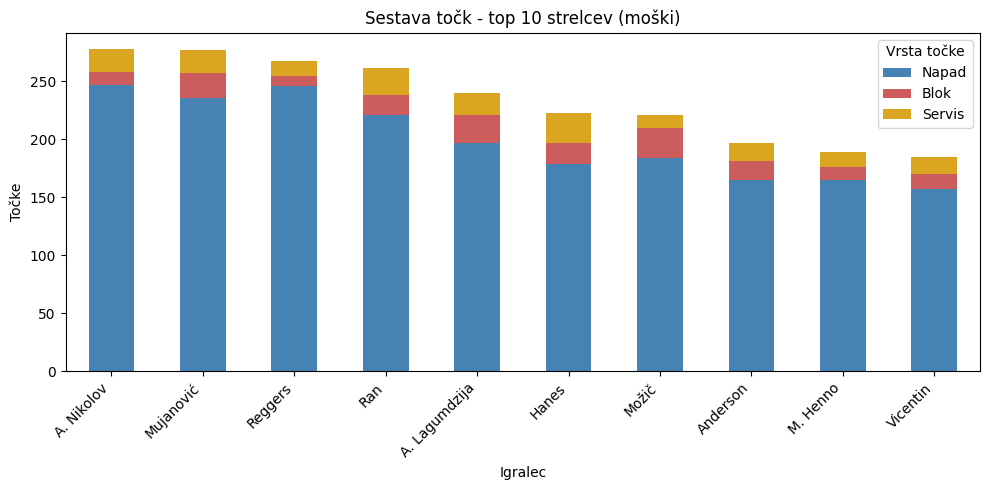

In [563]:
top10_moski_sestava = (
    igralci[igralci["spol"] == "M"]
    .sort_values(by="tocke_skupaj", ascending=False)
    .head(10)
    [["priimek", "tocke_napad", "tocke_blok", "tocke_servis"]]
    .set_index("priimek")
    .rename(columns={"tocke_napad": "Napad", "tocke_blok": "Blok", "tocke_servis": "Servis"})
)

top10_moski_sestava.plot(kind="bar", stacked=True, figsize=(10, 5), color=["steelblue", "indianred", "goldenrod"])
plt.title("Sestava točk - top 10 strelcev (moški)")
plt.xlabel("Igralec")
plt.ylabel("Točke")
plt.legend(title="Vrsta točke")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [564]:
top10_zenske = (
    igralci[igralci["spol"] == "Ž"]
    .sort_values(by="tocke_skupaj", ascending=False)
    .head(10)
    [["priimek", "drzava", "pozicija", "tocke_skupaj"]]
)
top10_zenske["tocke_skupaj"] = top10_zenske["tocke_skupaj"].astype(int)
top10_zenske.index = range(1, 11)
top10_zenske

,priimek,drzava,pozicija,tocke_skupaj
1,Van Ryk,Kanada,Korektorica,298
2,Vargas,Turčija,Korektorica,293
3,Zhuang Y.S.,Kitajska,Sprejemalka,264
4,Antropova,Italija,Sprejemalka,259
5,Ana Cristina,Brazilija,Sprejemalka,256
6,Wada,Japonska,Sprejemalka,237
7,Bergmann,Brazilija,Sprejemalka,235
8,Martin,Belgija,Korektorica,233
9,Ishikawa,Japonska,Sprejemalka,215
10,Sato,Japonska,Sprejemalka,193


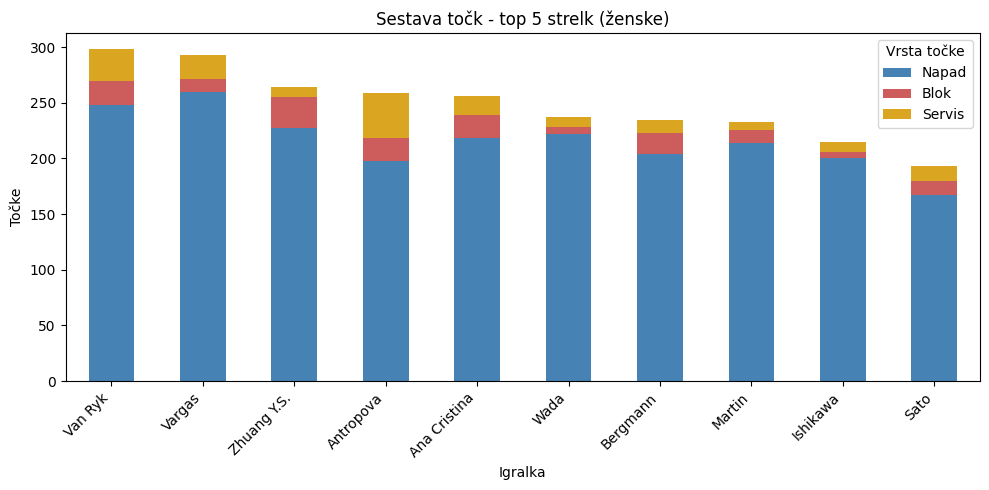

In [565]:
top10_zenske_sestava = (
    igralci[igralci["spol"] == "Ž"]
    .sort_values(by="tocke_skupaj", ascending=False)
    .head(10)
    [["priimek", "tocke_napad", "tocke_blok", "tocke_servis"]]
    .set_index("priimek")
    .rename(columns={"tocke_napad": "Napad", "tocke_blok": "Blok", "tocke_servis": "Servis"})
)

top10_zenske_sestava.plot(kind="bar", stacked=True, figsize=(10, 5), color=["steelblue", "indianred", "goldenrod"])
plt.title("Sestava točk - top 5 strelk (ženske)")
plt.xlabel("Igralka")
plt.ylabel("Točke")
plt.legend(title="Vrsta točke")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Opazimo, da so na seznamu samo napadalci/ke in korektorji/ce, kar je smiselno, saj v odbojki napad večinoma sloni na njih. Vidimo tudi, da večino točk igralci dosežejo iz napada, najmanj pa večinoma z blokom.

Ker pa osebno mislim, da število vseh doseženih točk ni edini kriterij za določanje najboljšega napadalca, si poglejmo še seznam najboljših napadalcev glede na učinkovitost v napadu. Gledali bomo le igralce, ki so dosegli vsaj 20 točk v napadu (igralci z npr. le 1 napadom imajo lahko 100% učinkovitost, kar je statistično zavajajoče in nas ne zanima).

In [566]:
top5_ucinkovitost_moski = (
    igralci[(igralci["spol"] == "M") & (igralci["tocke_napad"] >= 30)]
    .sort_values(by="ucinkovitost_napad", ascending=False)
    .head()
    [["priimek", "drzava", "pozicija", "tocke_napad", "ucinkovitost_napad"]]
)
top5_ucinkovitost_moski["tocke_napad"] = top5_ucinkovitost_moski["tocke_napad"].astype(int)
top5_ucinkovitost_moski.index = range(1, 6)
top5_ucinkovitost_moski

,priimek,drzava,pozicija,tocke_napad,ucinkovitost_napad
1,Shchurov,Ukrajina,Srednji bloker,57,69.51
2,Krick,Nemčija,Srednji bloker,60,68.97
3,Zhang Z.J.,Kitajska,Srednji bloker,33,68.75
4,Huetz,Francija,Srednji bloker,38,67.86
5,Gueye,Francija,Srednji bloker,31,67.39


In [567]:
top5_ucinkovitost_zenske = (
    igralci[(igralci["spol"] == "Ž") & (igralci["tocke_napad"] >= 30)]
    .sort_values(by="ucinkovitost_napad", ascending=False)
    .head()
    [["priimek", "drzava", "pozicija", "tocke_napad", "ucinkovitost_napad"]]
)
top5_ucinkovitost_zenske["tocke_napad"] = top5_ucinkovitost_zenske["tocke_napad"].astype(int)
top5_ucinkovitost_zenske.index = range(1, 6)
top5_ucinkovitost_zenske

,priimek,drzava,pozicija,tocke_napad,ucinkovitost_napad
1,Fahr,Italija,Srednja blokerka,102,60.71
2,Strubbe,Nemčija,Srednja blokerka,47,58.75
3,Danesi,Italija,Srednja blokerka,34,58.62
4,Rettke,ZDA,Srednja blokerka,41,55.41
5,Weitzel,Nemčija,Srednja blokerka,78,54.55


Tukaj lahko vidimo, da je situacija povsem drugačna - na lestvici so le srednji blokerji in blokerke. To je pričakovano, saj srednji blokerji dobijo veliko manj žog v napadu kot napadalci in korektorji, prav tako pa dobijo le 'idealne žoge'. Zato je njihova učinkovitost skoraj vedno višja od te od napadalcev in korektorjev.

## 4. Uspešnost v bloku glede na višino srednjega blokerja

Vemo že, da je višina v odbojki pomemben dejavnik. Zanima pa me, ali je uspešnost v bloku povezana z višino igralca, ali so še vedno pomembnejši drugi faktorji (npr. hitrost, timing,...). To bomo izvedeli iz naslednjega grafa (za večjo zanesljivost gledamo le igralce, ki so dosegli 5 ali več blokov).

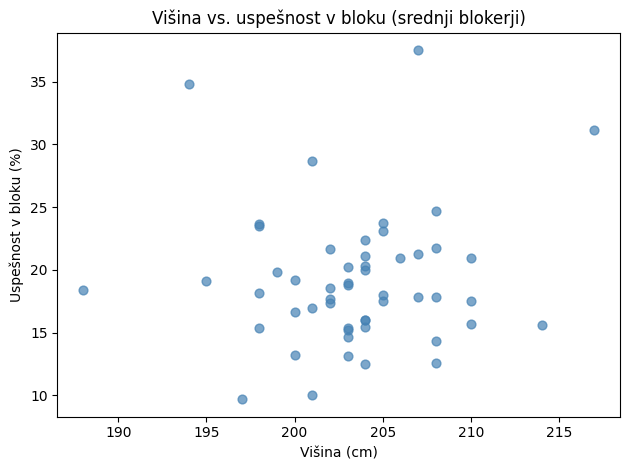

In [568]:
moski_blokerji = igralci[
    (igralci["spol"] == "M") &
    (igralci["pozicija"] == "Srednji bloker") &
    (igralci["tocke_blok"] >= 5)
]

plt.scatter(moski_blokerji["visina_cm"], moski_blokerji["uspesnost_blok"],
            color="steelblue", alpha=0.7, s=40)
plt.title("Višina vs. uspešnost v bloku (srednji blokerji)")
plt.xlabel("Višina (cm)")
plt.ylabel("Uspešnost v bloku (%)")
plt.tight_layout()
plt.show()

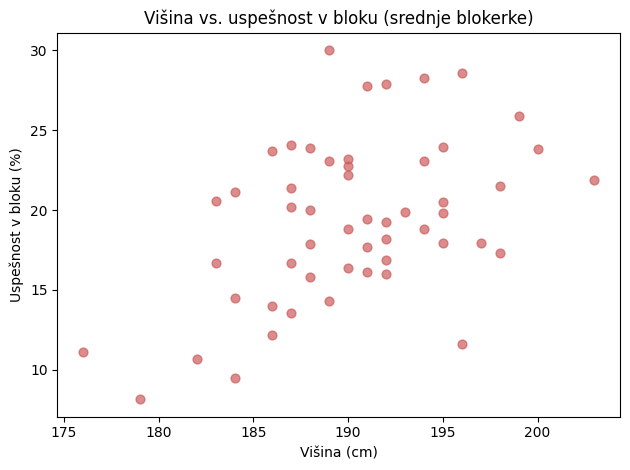

In [569]:
zenske_blokerke = igralci[
    (igralci["spol"] == "Ž") &
    (igralci["pozicija"] == "Srednja blokerka") &
    (igralci["tocke_blok"] >= 5)
]

plt.scatter(zenske_blokerke["visina_cm"], zenske_blokerke["uspesnost_blok"],
            color="indianred", alpha=0.7, s=40)
plt.title("Višina vs. uspešnost v bloku (srednje blokerke)")
plt.xlabel("Višina (cm)")
plt.ylabel("Uspešnost v bloku (%)")
plt.tight_layout()
plt.show()

Vidimo, da je višina pri ženskah nekoliko pomembnejša kot pri moških, saj lahko iz grafa lepo vidimo, da učinkovitost v bloku z višino igralke narašča. Za moške tega sklepa ne moremo narediti, saj je graf povsem razpršen in naše hipoteze ne pokaže zelo jasno.

## 5. Najboljši Slovenec

Osredotočimo se zdaj še na slovensko reprezentanco. Zanima me, kdo je najboljši igralec slovenske reprezentance na tem VNL-ju - s tem mislim na najbolj vsestranskega igralca, torej tistega, ki je bil najboljši v največ statističnih elementih.

In [570]:
slovenija_moski = igralci[(igralci["drzava"] == "Slovenija")]

stolpci_za_analizo = {
    "tocke_skupaj": "Skupaj točk",
    "tocke_napad": "Točke iz napada",
    "ucinkovitost_napad": "Učinkovitost napada (%)",
    "tocke_blok": "Točke iz bloka",
    "uspesnost_blok": "Uspešnost bloka (%)",
    "tocke_servis": "Točke iz servisa",
    "uspesnost_servis": "Uspešnost servisa (%)",
}

najboljsi_po_kategorijah = []

for stolpec, ime_kategorije in stolpci_za_analizo.items():

    podatki = slovenija_moski

    indeks_najboljsega = podatki[stolpec].idxmax()

    vrstica_najboljsega = podatki.loc[indeks_najboljsega]

    najboljsi_po_kategorijah.append({
        "Kategorija": ime_kategorije,
        "Najboljši Slovenec": vrstica_najboljsega["priimek"],
        "Vrednost": vrstica_najboljsega[stolpec],
    })

najboljsi_tabela = pd.DataFrame(najboljsi_po_kategorijah)
najboljsi_tabela.index += 1
najboljsi_tabela



,Kategorija,Najboljši Slovenec,Vrednost
1,Skupaj točk,Mujanović,277.00
2,Točke iz napada,Mujanović,236.00
3,Učinkovitost napada (%),Kržič,90.00
4,Točke iz bloka,Kozamernik,28.00
5,Uspešnost bloka (%),Možič,24.07
6,Točke iz servisa,Mujanović,20.00
7,Uspešnost servisa (%),Marovt,11.76


In [571]:
najboljsi_tabela["Najboljši Slovenec"].value_counts()

Najboljši Slovenec
Mujanović     3
Kržič         1
Kozamernik    1
Možič         1
Marovt        1
Name: count, dtype: int64

Torej je bil po našem kriteriju na letošnjem VNL-ju najboljši Slovenec Nik Mujanović, saj je bil statistično najboljši kar v treh kategorijah.

Poglejmo si sedaj še razporeditev točk med igralci slovenske reprezentance. S tem bomo videli, ali je ekipa odvisna predvsem od enega igralca ali je ekipa dokaj 'uravnotežena'.

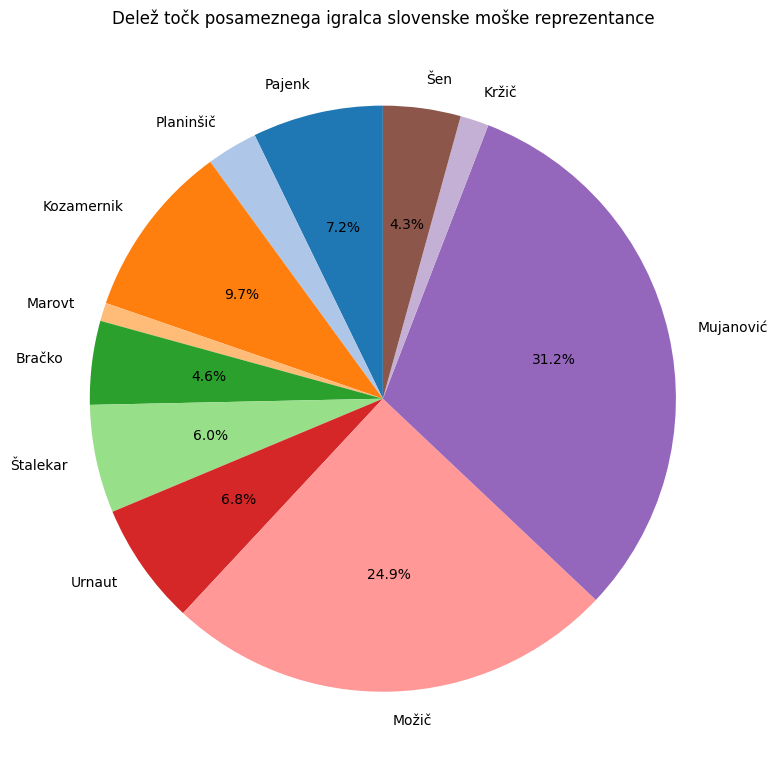

In [572]:
slovenija_tocke = slovenija_moski.dropna(subset=["tocke_skupaj"])
slovenija_tocke = slovenija_tocke[slovenija_tocke["tocke_skupaj"] > 5]

barve = plt.cm.tab20(range(len(slovenija_tocke)))

def prikazi(odstotek):
    return f"{odstotek:.1f}%" if odstotek >= 3 else ""

plt.figure(figsize=(8, 8))
plt.pie(
    slovenija_tocke["tocke_skupaj"],
    labels=slovenija_tocke["priimek"],
    autopct=prikazi, 
    startangle=90,
    colors=barve
)
plt.title("Delež točk posameznega igralca slovenske moške reprezentance")
plt.tight_layout()
plt.show()

Iz prikaza je razvidno, da porazdelitev ni zelo enakomerna - prevladujeta 2 igralca, ki sta skupaj dosegla več kot polovico vseh slovenskih točk. Torej slovenska igra ni ravno 'uravnotežena', a vsaj sloni na dveh glavnih igralcih, ne le na enem.

## 6. Skupno število točk glede na številko na dresu

Za konec si poglejmo še eno za statistike bolj neuporabno, a zabavno statistiko. Najprej si poglejmo 10 najbolj popularnih številk na dresih, nato pa še koliko točk so skupaj dosegli igralci in igralke vseh reprezentanc z enako številko na dresu in seveda katera številka bo zmagovalka. 

In [573]:
top10_stevilke_tabela = (
    igralci["st_dresa"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_stevilke_tabela.columns = ["Številka dresa", "Število igralcev"]
top10_stevilke_tabela.index += 1
top10_stevilke_tabela

,Številka dresa,Število igralcev
1,8,26
2,3,24
3,11,24
4,18,24
5,16,23
6,7,22
7,4,21
8,1,20
9,22,20
10,9,20


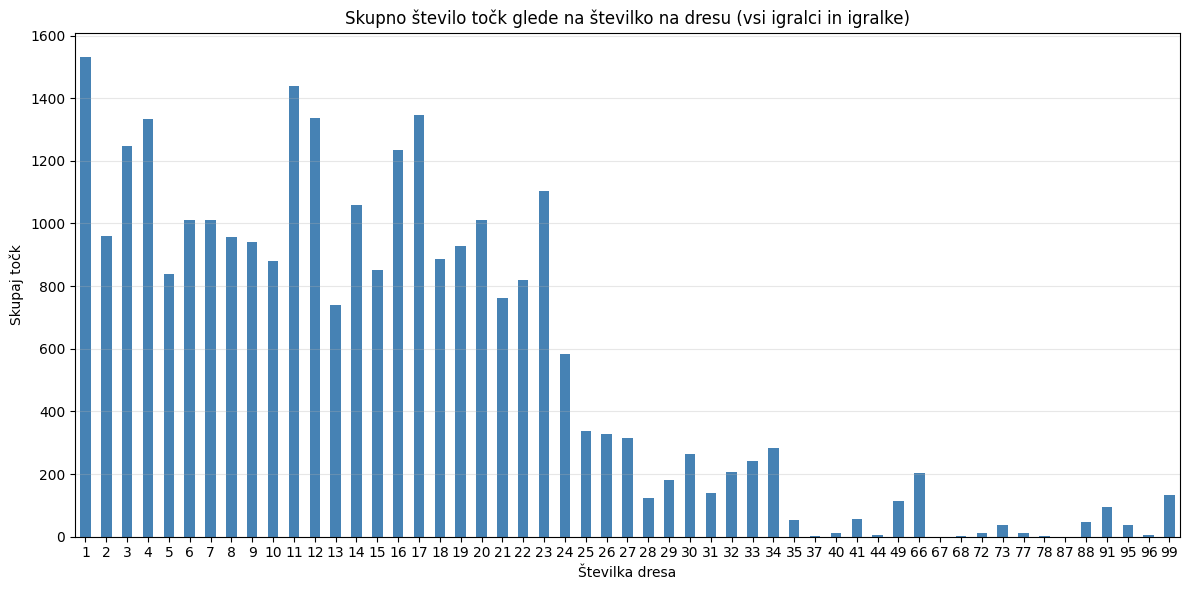

In [574]:
tocke_po_stevilki = (
    igralci.groupby("st_dresa")["tocke_skupaj"]
    .sum()
    .sort_index()
)

tocke_po_stevilki.plot(kind="bar", figsize=(12, 6), color="steelblue")
plt.title("Skupno število točk glede na številko na dresu (vsi igralci in igralke)")
plt.xlabel("Številka dresa")
plt.ylabel("Skupaj točk")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [575]:
zmagovalna_stevilka = tocke_po_stevilki.idxmax()
najvec_tock = tocke_po_stevilki.max()

print(f"Zmagovalna številka dresa je številka #{zmagovalna_stevilka} s skupaj {najvec_tock:.0f} točkami.")

Zmagovalna številka dresa je številka #1 s skupaj 1532 točkami.


In [576]:
stevilo_razlicnih_stevilk = igralci["st_dresa"].nunique()
print(f"V VNL je igralo skupaj {stevilo_razlicnih_stevilk} različnih številk na dresu.")

V VNL je igralo skupaj 53 različnih številk na dresu.


Torej smo ugotovili, da je zmagovalna številka kar številka #1. To je kar zanimivo, glede na to da se po popularnosti pojavi šele na 8. mestu, torej je k skupnim točkam prispevalo manj igralcev kot pri nekaterih drugih številkah. 

Vidimo tudi, da se je na dresih pojavilo kar 53 različnih številk, kar je več kot polovica vseh možnih izbir.